# Running a POPCON with P_auxillary_launched as input instead of average_electron_temperature

First, we import necessary libraries and functions. 

In [1]:
%reload_ext autoreload
%autoreload 2

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import cfspopcon
from cfspopcon.unit_handling import Quantity, ureg, wraps_ufunc
from cfspopcon.algorithm_class import Algorithm, CompositeAlgorithm
from cfspopcon.formulas.energy_confinement.read_energy_confinement_scalings import ConfinementScaling

# Change to the top-level directory. Required to find radas_dir in its default location.
%cd {Path(cfspopcon.__file__).parents[1]}
# As a sanity check, print out the current working directory
print(f"Running in {Path('').absolute()}")

/mnt/home/audreysa/cfspopcon
Running in /mnt/home/audreysa/cfspopcon


We read in the SPARC_PRD input file: 

In [2]:
input_parameters, algorithm_original, points, plots  = cfspopcon.read_case("example_cases/SPARC_PRD")

Using the .algorithms method we can see what algorithms are a part of algorithm_original, as specificed by the input.yaml file. 

In [3]:
algorithm_original.algorithms

[Algorithm: read_atomic_data,
 Algorithm: set_up_impurity_concentration_array,
 Algorithm: calc_separatrix_elongation_from_areal_elongation,
 Algorithm: calc_separatrix_triangularity_from_triangularity95,
 Algorithm: calc_minor_radius_from_inverse_aspect_ratio,
 Algorithm: calc_vertical_minor_radius_from_elongation_and_minor_radius,
 Algorithm: calc_plasma_volume,
 Algorithm: calc_plasma_surface_area,
 Algorithm: calc_f_shaping_for_qstar,
 Algorithm: calc_q_star_from_plasma_current,
 Algorithm: calc_average_ion_mass,
 Algorithm: calc_average_ion_temp_from_temperature_ratio,
 Algorithm: calc_zeff_and_dilution_due_to_impurities,
 Algorithm: calc_plasma_stored_energy,
 Algorithm: read_confinement_scalings,
 Algorithm: solve_energy_confinement_scaling_for_input_power,
 Algorithm: calc_beta_toroidal,
 Algorithm: calc_beta_poloidal,
 Algorithm: calc_beta_total,
 Algorithm: calc_beta_normalized,
 Algorithm: calc_peaked_profiles,
 Algorithm: calc_intrinsic_radiated_power_from_core,
 Algorithm:

We run the standard POPCON with the average_electron_temp as input. This generates the base set of quantities we need to start our iteration of average_electron_temps consistent with our desired values of P_auxillary_launched

In [4]:

ds = xr.Dataset(input_parameters)
ds = algorithm_original.update_dataset(ds)
ds_copy = ds.copy()


It is easiest to generate a set of dim_P_auxillary_launched coordinates with the same dimensions as the dim_average_electron_temp coordinates. We can see those dimensions here: 


In [5]:
num_Te_coordiantes = ds.dims['dim_average_electron_temp']

/tmp/ipykernel_1761104/3014466565.py:1: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  num_Te_coordiantes = ds.dims['dim_average_electron_temp']


N.b.: the following cell will fail if you run it more than once without restarting the kernal

In [6]:
# P_aux_min = 0MW, P_aux_max = 25MW for SPARC PRD
from cfspopcon.unit_handling import magnitude_in_units
P_aux_coord = np.linspace(0,25,num_Te_coordiantes) * ureg.MW
ds = ds.assign_coords({"dim_average_electron_temp": magnitude_in_units(P_aux_coord, ureg.MW)})
ds = ds.rename({"dim_average_electron_temp": "dim_P_auxiliary_launched"})

In [7]:
ds['P_auxiliary_launched'] = xr.DataArray(P_aux_coord, dims='dim_P_auxiliary_launched')
ds['P_auxiliary_launched']

Magnitude,[0.0 0.8620689655172413 1.7241379310344827 2.586206896551724 3.4482758620689653 4.310344827586206 5.172413793103448 6.0344827586206895 6.896551724137931 7.758620689655172 8.620689655172413 9.482758620689655 10.344827586206897 11.206896551724137 12.068965517241379 12.93103448275862 13.793103448275861 14.655172413793103 15.517241379310343 16.379310344827584 17.241379310344826 18.103448275862068 18.96551724137931 19.82758620689655 20.689655172413794 21.551724137931032 22.413793103448274 23.275862068965516 24.137931034482758 25.0]
Units,megawatt


In [8]:

ds['P_auxillary_absorbed'] = ds['P_auxiliary_launched'] * ds['fraction_of_external_power_coupled']
ds['P_auxillary_absorbed']

Magnitude,[0.0 0.7758620689655172 1.5517241379310345 2.327586206896552 3.103448275862069 3.879310344827586 4.655172413793104 5.431034482758621 6.206896551724138 6.982758620689655 7.758620689655172 8.53448275862069 9.310344827586208 10.086206896551724 10.862068965517242 11.637931034482758 12.413793103448276 13.189655172413794 13.96551724137931 14.741379310344826 15.517241379310343 16.29310344827586 17.06896551724138 17.844827586206897 18.620689655172416 19.39655172413793 20.17241379310345 20.948275862068964 21.724137931034484 22.5]
Units,megawatt


### We can calculate the input power consistent with the P_auxillary_launched. The P_ohmic and P_alpha are consistent with the originally assumed average_electron_temp at each grid point. 

In [9]:
ds['P_in']= ds['P_auxillary_absorbed'] + ds['P_ohmic'] + ds['P_alpha']

Here's a slightly round about way to plot P_auxillary_absorbed: 

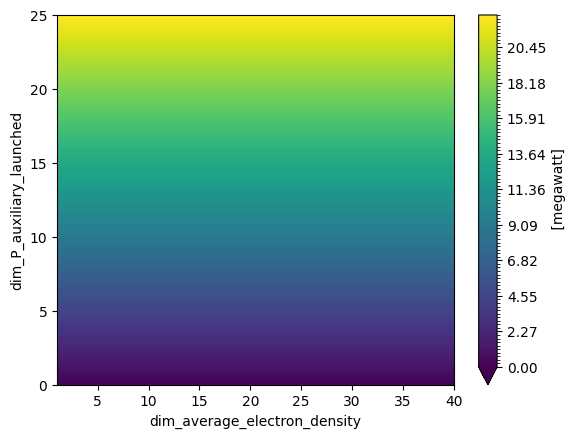

In [10]:

(ds['P_in'] - ds['P_alpha']- ds['P_ohmic']).plot.contourf(levels = 100, vmin = 0) 

Here's a plot of P_in: 

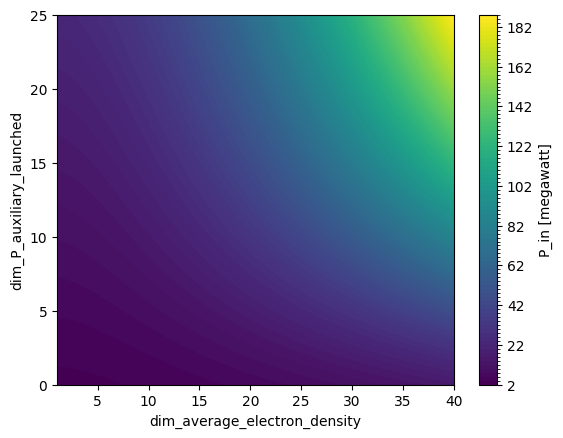

In [11]:
ds['P_in'].plot.contourf(levels = 100)

### Now we need to make a function to calculate the energy confinement time given a P_in

In [12]:
@Algorithm.register_algorithm(return_keys=["energy_confinement_time"])
@wraps_ufunc(
    return_units=dict(tau_e=ureg.s),
    input_units=dict(
        confinement_time_scalar=ureg.dimensionless,
        plasma_current=ureg.MA,
        magnetic_field_on_axis=ureg.T,
        average_electron_density=ureg.n19,
        major_radius=ureg.m,
        areal_elongation=ureg.dimensionless,
        separatrix_elongation=ureg.dimensionless,
        inverse_aspect_ratio=ureg.dimensionless,
        average_ion_mass=ureg.amu,
        triangularity_psi95=ureg.dimensionless,
        separatrix_triangularity=ureg.dimensionless,
        P_in = ureg.MW,
        q_star=ureg.dimensionless,
        energy_confinement_scaling=None,
    ),
    output_core_dims=[()],
)
def calc_energy_confinement_time_from_P_in(
    confinement_time_scalar: float,
    plasma_current: float,
    magnetic_field_on_axis: float,
    average_electron_density: float,
    major_radius: float,
    areal_elongation: float,
    separatrix_elongation: float,
    inverse_aspect_ratio: float,
    average_ion_mass: float,
    triangularity_psi95: float,
    separatrix_triangularity: float,
    P_in: float,
    q_star: float,
    energy_confinement_scaling: str,
) -> float:
    r"""Calculate the energy confinement time from the input power.

    Args:
        confinement_time_scalar: [~] confinement scaling factor
        plasma_current: [MA] :term:`glossary link<plasma_current>`
        magnetic_field_on_axis: [T] :term:`glossary link<magnetic_field_on_axis>`
        average_electron_density: [1e19 m^-3] :term:`glossary link<average_electron_density>`
        major_radius: [m] :term:`glossary link<major_radius>`
        areal_elongation: [~] :term:`glossary link<areal_elongation>`
        separatrix_elongation: [~] :term:`glossary link<separatrix_elongation>`
        inverse_aspect_ratio: [~] :term:`glossary link<inverse_aspect_ratio>`
        average_ion_mass: [amu] :term:`glossary link<average_ion_mass>`
        triangularity_psi95: [~] :term:`glossary link<triangularity_psi95>`
        separatrix_triangularity: [~] :term:`glossary link<separatrix_triangularity>`
        P_in: [MW] :term:`glossary link<P_in>`
        q_star: [~] :term:`glossary link<q_star>`
        energy_confinement_scaling: [] :term:`glossary link<energy_confinement_scaling>`

    Returns:
        :term:`energy_confinement_time` [s], 
    """
    scaling = ConfinementScaling.instances[energy_confinement_scaling]

    energy_confinement_time = (
        confinement_time_scalar
        * scaling.constant
        * plasma_current**scaling.plasma_current_alpha
        * magnetic_field_on_axis**scaling.field_on_axis_alpha
        * average_electron_density**scaling.average_density_alpha
        * major_radius**scaling.major_radius_alpha
        * areal_elongation**scaling.areal_elongation_alpha
        * separatrix_elongation**scaling.separatrix_elongation_alpha
        * inverse_aspect_ratio**scaling.inverse_aspect_ratio_alpha
        * average_ion_mass**scaling.mass_ratio_alpha
        * P_in**scaling.input_power_alpha
        * (1.0 + np.mean([triangularity_psi95, separatrix_triangularity])) ** scaling.triangularity_alpha
        * q_star**scaling.qstar_alpha
    )

    return energy_confinement_time


In [13]:
algorithm2 = Algorithm.get_algorithm("calc_energy_confinement_time_from_P_in")
ds = algorithm2.update_dataset(ds)

Compare the original energy confinement time in average_electron_temp space with P_auxillary_launched space

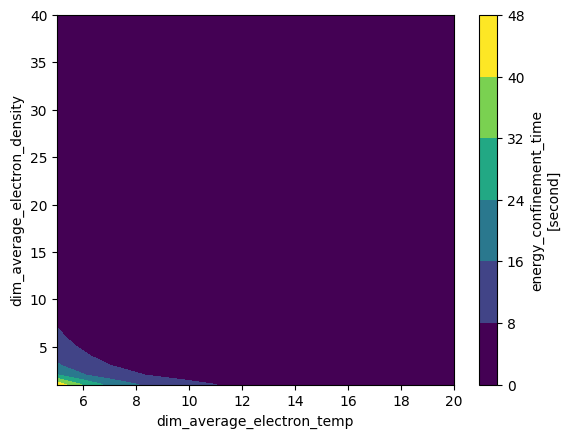

In [14]:
ds_copy['energy_confinement_time'].plot.contourf()

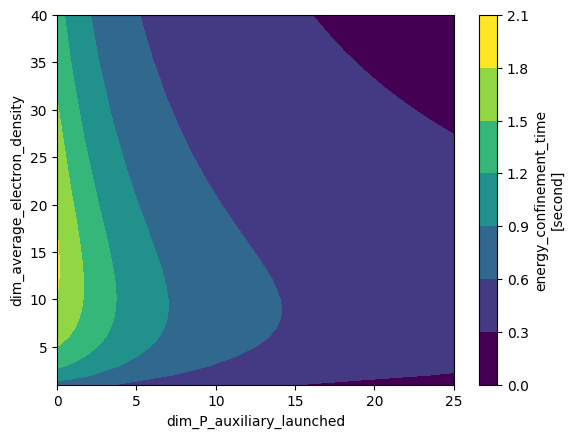

In [15]:
ds['energy_confinement_time'].plot.contourf()

Calculate the stored energy consistent with our enforced Pin and energy_confinement_time

In [16]:
ds['plasma_stored_energy'] = ds['energy_confinement_time'] * ds['P_in']
ds['plasma_stored_energy'] = ds['plasma_stored_energy'].pint.to(ureg.MJ)

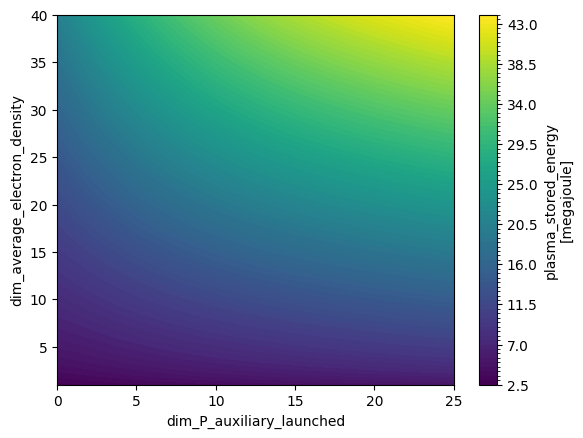

In [17]:
ds['plasma_stored_energy'].plot.contourf(levels = 100)

### Now, we will calculate the average_electron_temperature consistent with this plasma_stored_energy

In [18]:
from cfspopcon.named_options import AtomicSpecies
ds['impurity_concentration'].sel(dim_species=AtomicSpecies.Tungsten)

Magnitude,[[1.5e-05 1.5e-05 1.5e-05 ... 1.5e-05 1.5e-05 1.5e-05] [1.5e-05 1.5e-05 1.5e-05 ... 1.5e-05 1.5e-05 1.5e-05] [1.5e-05 1.5e-05 1.5e-05 ... 1.5e-05 1.5e-05 1.5e-05] ... [1.5e-05 1.5e-05 1.5e-05 ... 1.5e-05 1.5e-05 1.5e-05] [1.5e-05 1.5e-05 1.5e-05 ... 1.5e-05 1.5e-05 1.5e-05] [1.5e-05 1.5e-05 1.5e-05 ... 1.5e-05 1.5e-05 1.5e-05]]
Units,dimensionless


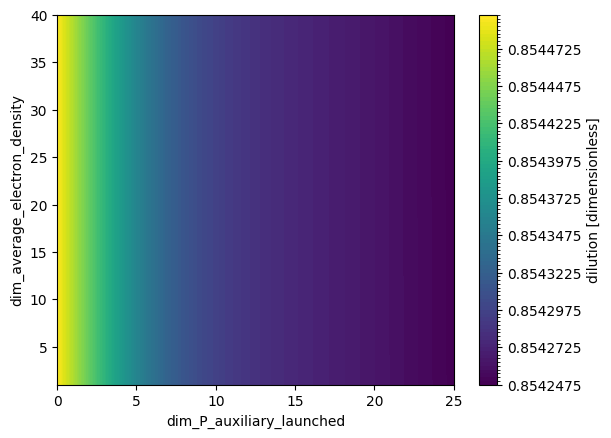

In [19]:
# ds['z_effective'].plot.contourf(levels = 100)
# ds['summed_impurity_density'].plot.contourf(levels = 100)
ds['dilution'].plot.contourf(levels = 100)

In [20]:
# This updates the z_effective and summed_impurity_density
algorithm = Algorithm.get_algorithm("calc_zeff_and_dilution_due_to_impurities")
ds = algorithm.update_dataset(ds)

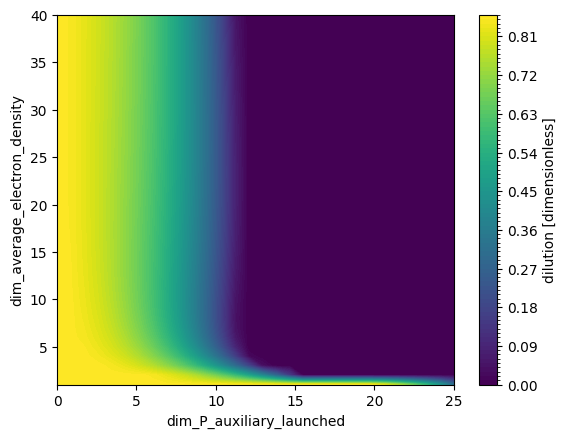

In [21]:
# ds['z_effective'].plot.contourf(levels = 100)
# ds['summed_impurity_density'].plot.contourf(levels = 100)
ds['dilution'].plot.contourf(levels = 100)

In [22]:

# print(ds['average_ion_temp'].shape)
algorithm = Algorithm.get_algorithm("calc_average_ion_temp_from_temperature_ratio")
ds = algorithm.update_dataset(ds)


In [23]:
summed_impurity_concentration = ds['summed_impurity_density'] / ds['average_electron_density']
denominator = 3 * ds['plasma_volume'] * (1 + (ds['dilution'] + summed_impurity_concentration) * ds['ion_to_electron_temp_ratio']) * ds['average_electron_density'] 
denominator = denominator.pint.to(ureg.dimensionless)

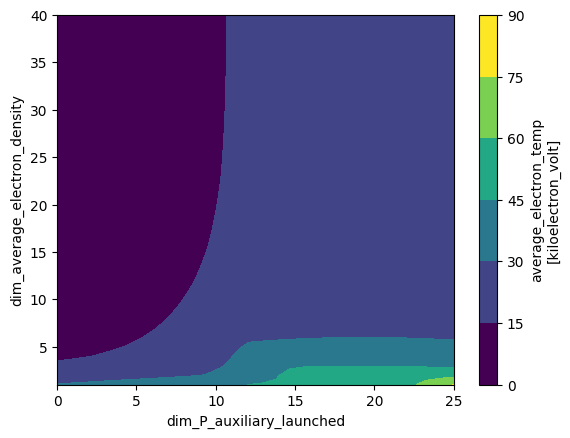

In [24]:
ds['average_electron_temp'] = 2 * ds['plasma_stored_energy'] / denominator
ds['average_electron_temp'] = ds['average_electron_temp'].pint.to(ureg.keV)
ds['average_electron_temp'].plot.contourf()

## We need to repeat the iteration of calculating the average_electron_temp until P_alpha and P_ohmic are consistent with both P_in and electron_avg_temp

First, we will double check the calculated stored energy is the same with our new average_electron_temps as we has calcualted with. N.b. The follow cell will fail if run multiple times becaues multiple algorithms can't be registered with the same name. 

Make average_ion_temp consistent with average_electron_temp given the ion_to_electron_temperature_ratio

In [25]:
ds['average_electron_temp']

Magnitude,[[30.895089738364668 31.70626220588465 32.716520057141736 ... 63.181723351293236 68.55969621222282 75.78216914035458] [20.560543322848524 21.115937331013356 21.802510233956095 ... 56.1967481256788 55.87998060247316 55.50080349477409] [16.24200522731063 16.69852099491792 17.256972579312162 ... 43.113247140725015 42.8538390637418 42.55272874214263] ... [5.59597901534071 6.047215025655584 6.549983144496986 ... 16.847719727975537 16.595639305785493 16.31888181996805] [5.573992511029452 6.026115094232763 6.528758411820141 ... 16.77985404161466 16.525960154290413 16.24749031231706] [5.553251760457745 6.0061777711939515 6.5086711850254115 ... 16.714514782376575 16.45885894300142 16.17872833848387]]
Units,kiloelectron_volt


In [26]:

# print(ds['average_ion_temp'].shape)
algorithm = Algorithm.get_algorithm("calc_average_ion_temp_from_temperature_ratio")
ds = algorithm.update_dataset(ds)

In [31]:
algorithm = Algorithm.get_algorithm("calc_plasma_stored_energy")
ds = algorithm.update_dataset(ds)

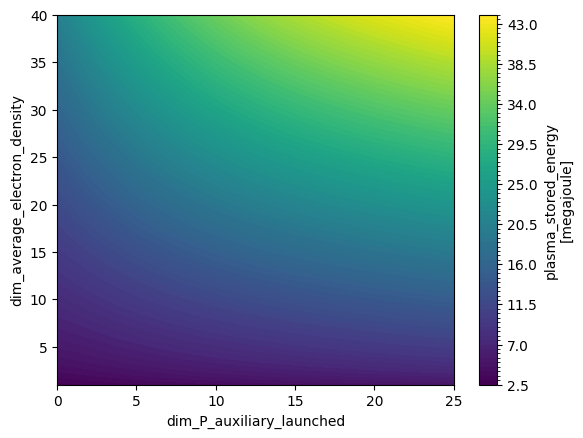

In [32]:
ds['plasma_stored_energy'].plot.contourf(levels = 100)